In [41]:
import numpy as np
from env import RaceEnviroment
import matplotlib.pyplot as plt

# Funktionen

In [42]:
def make_Q(race):
    n_actions = len(race.actions)
    coords = np.argwhere(np.isin(race.track, [1, 2, 3])) 
    n_states = np.sum(np.isin(race.track, [1, 2, 3]))

    Q = np.zeros((n_states, n_actions))
    # terminal_mask = race.track[coords[:,0], coords[:,1]] == 3
    # Q[terminal_mask,:] = 0
    
    return Q, coords

def make_Pi(race):
    n_states = np.sum(np.isin(race.track, [1, 2, 3]))
    n_actions = len(race.actions)

    Pi = np.zeros((n_states, n_actions), dtype=float)
    return Pi

def choose_A(S, Q, coords, race, epsilon=0.1):
    state_index = state_to_index(S, coords)
    if np.random.rand() < epsilon:
        return np.random.choice(len(race.actions))
    else:
        return np.argmax(Q[state_index, :])

def state_to_index(S, coords):
    """S ist ein Tupel (y,x), coords ist array von allen Zuständen"""
    return np.where((coords[:,0] == S[0]) & (coords[:,1] == S[1]))[0][0]

def update_pi(Pi, Q, epsilon):
    n_states, n_actions = Q.shape

    for s in range(n_states):
        # beste Aktion
        best_a = np.argmax(Q[s])

        # alle Aktionen erstmal gleich verteilen (ε-Exploration)
        Pi[s, :] = epsilon / n_actions

        # beste Aktion bekommt (1 - ε) extra
        Pi[s, best_a] += 1 - epsilon
    
    return Pi


# Main

In [43]:
race = RaceEnviroment("b", 5, 0, -1)

gamma = 1
alpha = 0.4
epsilon = 0.05
required_steps = []

Q, coords = make_Q(race)
Pi = make_Pi(race)
episodes = 10000

Action 1: [1, 1]
Action 2: [1, 0]
Action 3: [1, -1]
Action 4: [0, 1]
Action 5: [0, 0]
Action 6: [0, -1]
Action 7: [-1, 1]
Action 8: [-1, 0]
Action 9: [-1, -1]

Starting Position: (3, 1)



In [44]:
for i_episode in range(episodes):
    iteration = 1
    race.reset()
    S = (race.y, race.x)
    A = choose_A(S, Q, coords, race, epsilon)
    S_idx = state_to_index(S, coords)

    while True:
        R, next_S = race.step(A+1)

        if R == -1:
            next_A = choose_A(next_S, Q, coords, race, epsilon)
            next_S_idx = state_to_index(next_S, coords)
            Q[S_idx][A] += alpha * (R + gamma * Q[next_S_idx][next_A] - Q[S_idx][A])
        else:
            Q[S_idx][A] += alpha * (R - Q[S_idx][A])
            break
        
        A = next_A
        S = next_S
        S_idx = next_S_idx
        iteration += 1
        
    Pi = update_pi(Pi, Q, epsilon)
    required_steps += [iteration]

Starting Position: (1, 1)

Current Position: (2,2)
Current Position: (4,4)
--------------
You went Out Of Bounds!
--------------

Starting Position: (2, 1)

Current Position: (3,2)
Current Position: (5,4)
--------------
You went Out Of Bounds!
--------------

Starting Position: (1, 1)

Current Position: (2,1)
Current Position: (4,1)
--------------
You went Out Of Bounds!
--------------

Starting Position: (1, 1)

Current Position: (2,1)
Current Position: (4,1)
--------------
You went Out Of Bounds!
--------------

Starting Position: (3, 1)

Current Position: (4,2)
--------------
You went Out Of Bounds!
--------------

Starting Position: (3, 1)

Current Position: (3,1)
Current Position: (3,1)
Current Position: (4,1)
--------------
You went Out Of Bounds!
--------------

Starting Position: (3, 1)

Current Position: (4,1)
--------------
You went Out Of Bounds!
--------------

Starting Position: (2, 1)

Current Position: (2,2)
Current Position: (3,3)
Current Position: (5,5)
--------------


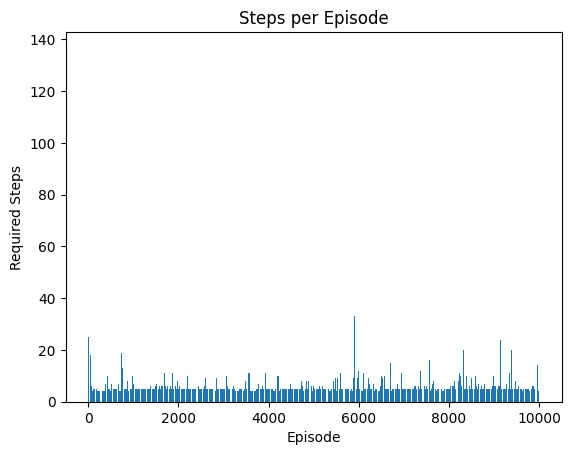

In [ ]:
plt.figure()
plt.bar(range(len(required_steps)), required_steps)
plt.xlabel("Episode")
plt.ylabel("Required Steps")
plt.title("Steps per Episode")
plt.show()